In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import boto3
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import catboost as cb
except:
    ! pip install catboost

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-04 23:15:00.044285


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

Project: 20241112-simple-model-test
Task: 09_60_in_720


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,linkf206__tu,linkf207__tu,linkf208__tu,linkf209__tu,linkf210__tu,linkf211__tu,linkf212__tu,linkf213__tu,totalincome__app,totaldebt__app
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,0.0,235.0,0.0,4.0,0.0,1005.0,0.0,0.48,NaN,NaN
0,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0.0,0.0,0.0,0.0,7.0,0.0,1166.0,0.95,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Import preprocessor

In [7]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    str_bucket_path = f'01_ad/02_model/noPTImodel10/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path,
        str_bucket_path=str_bucket_path,
        str_project='20231010-gen-xii',
    )
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

#### Preprocess data

In [8]:
df = cls_model_preprocessing.transform(df)
# rm
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    os.remove(str_filename)
# show
df

NaN Replacer: 0.2055 sec.


100%|██████████| 3/3 [00:00<00:00, 325.91it/s]

Set strings: 0.011832 sec.


Boolean Replacer: 0.26746 sec.


100%|██████████| 1937/1937 [00:01<00:00, 1618.27it/s]


...

Replace inf and -inf with NaN: 1.1351 sec.
Imputer: 0.39983 sec.
Map term: 0.0071382 sec.
Map PTI: 0.0061295 sec.


100%|██████████| 6/6 [00:00<00:00, 2052.34it/s]


Round values: 0.006798 sec.
Preprocessing Model: 4.9447 sec.


100%|██████████| 2/2 [00:00<00:00, 1306.64it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,totalincome__app,totaldebt__app,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574.0,10419817.0,1.0,illinois,...,0.0,0.00,2024,0.940900,12,4,0.15,0.924528,-1.0,1.183562
0,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134.0,10562333.0,1.0,utah,...,0.0,0.00,2025,0.912673,1,1,0.15,1.130435,6.0,9.657534
0,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707.0,10475697.0,1.0,california,...,0.0,0.00,2024,0.940900,12,4,0.06,1.060000,2.0,0.632877
0,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640.0,10551081.0,1.0,indiana,...,0.0,0.00,2025,0.912673,1,1,0.15,0.869565,5.0,0.468493
0,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624.0,10403122.0,1.0,wisconsin,...,0.0,0.00,2024,0.940900,11,4,0.09,1.044444,5.0,10.616438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699.0,10574753.0,1.0,oklahoma,...,5560.0,2742.65,2025,0.912673,1,1,0.15,1.258065,5.0,0.361644
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699.0,10574754.0,0.0,oklahoma,...,5560.0,2742.65,2025,0.912673,1,1,0.15,1.258065,5.0,0.361644
0,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513.0,10520070.0,1.0,maryland,...,0.0,0.00,2024,0.940900,12,4,0.06,1.097561,4.0,1.134247
0,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878.0,10494193.0,1.0,ohio,...,0.0,0.00,2024,0.940900,12,4,0.15,1.211538,-1.0,8.917808


#### PD predictions

In [9]:
str_filename = 'final_model.pkl'
str_model = '02_pricing_pd'
str_bucket_path = f'{str_model}/02_model/noPTImodel10/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20231010-gen-xii',
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['pd'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,totaldebt__app,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574.0,10419817.0,1.0,illinois,...,0.00,2024,0.940900,12,4,0.15,0.924528,-1.0,1.183562,0.138263
0,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134.0,10562333.0,1.0,utah,...,0.00,2025,0.912673,1,1,0.15,1.130435,6.0,9.657534,0.189794
0,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707.0,10475697.0,1.0,california,...,0.00,2024,0.940900,12,4,0.06,1.060000,2.0,0.632877,0.179454
0,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640.0,10551081.0,1.0,indiana,...,0.00,2025,0.912673,1,1,0.15,0.869565,5.0,0.468493,0.250014
0,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624.0,10403122.0,1.0,wisconsin,...,0.00,2024,0.940900,11,4,0.09,1.044444,5.0,10.616438,0.096776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699.0,10574753.0,1.0,oklahoma,...,2742.65,2025,0.912673,1,1,0.15,1.258065,5.0,0.361644,0.590747
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699.0,10574754.0,0.0,oklahoma,...,2742.65,2025,0.912673,1,1,0.15,1.258065,5.0,0.361644,0.365442
0,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513.0,10520070.0,1.0,maryland,...,0.00,2024,0.940900,12,4,0.06,1.097561,4.0,1.134247,0.266623
0,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878.0,10494193.0,1.0,ohio,...,0.00,2024,0.940900,12,4,0.15,1.211538,-1.0,8.917808,0.242951


#### LGD predictions

In [10]:
str_filename = 'final_model.pkl'
str_model = '03_pricing_lgd'
str_bucket_path = f'{str_model}/02_model/noPTImodel10/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20231010-gen-xii',
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['lgd'] = cls_model_inference.predict(df[list_cols_model])
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd,lgd
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574.0,10419817.0,1.0,illinois,...,2024,0.940900,12,4,0.15,0.924528,-1.0,1.183562,0.138263,0.648218
0,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134.0,10562333.0,1.0,utah,...,2025,0.912673,1,1,0.15,1.130435,6.0,9.657534,0.189794,0.656812
0,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707.0,10475697.0,1.0,california,...,2024,0.940900,12,4,0.06,1.060000,2.0,0.632877,0.179454,0.574378
0,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640.0,10551081.0,1.0,indiana,...,2025,0.912673,1,1,0.15,0.869565,5.0,0.468493,0.250014,0.707335
0,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624.0,10403122.0,1.0,wisconsin,...,2024,0.940900,11,4,0.09,1.044444,5.0,10.616438,0.096776,0.622867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699.0,10574753.0,1.0,oklahoma,...,2025,0.912673,1,1,0.15,1.258065,5.0,0.361644,0.590747,0.628667
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699.0,10574754.0,0.0,oklahoma,...,2025,0.912673,1,1,0.15,1.258065,5.0,0.361644,0.365442,0.631306
0,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513.0,10520070.0,1.0,maryland,...,2024,0.940900,12,4,0.06,1.097561,4.0,1.134247,0.266623,0.584514
0,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878.0,10494193.0,1.0,ohio,...,2024,0.940900,12,4,0.15,1.211538,-1.0,8.917808,0.242951,0.629542


#### Subset

In [11]:
list_cols = [
    'accountid',
    'request_datetime',
    'response_model_name',
    'bitdebtor',
    'pd',
    'lgd',
]
df = df[list_cols].copy()
# show
df

,accountid,request_datetime,response_model_name,bitdebtor,pd,lgd
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,1,0.138263,0.648218
0,8564134,2025-01-14 07:37:54+00:00,GEN-XII,1,0.189794,0.656812
0,8489707,2024-12-15 06:08:17+00:00,GEN-XII,1,0.179454,0.574378
0,8554640,2025-01-10 05:31:51+00:00,GEN-XII,1,0.250014,0.707335
0,8425624,2024-11-26 22:41:51+00:00,GEN-XII,1,0.096776,0.622867
...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,1,0.590747,0.628667
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,0,0.365442,0.631306
0,8528513,2024-12-29 04:14:24+00:00,GEN-XII,1,0.266623,0.584514
0,8506878,2024-12-19 02:10:09+00:00,GEN-XII,1,0.242951,0.629542


#### Save locally

In [12]:
%%time

str_filename = 'df_predictions.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

CPU times: user 44.6 ms, sys: 4.74 ms, total: 49.3 ms
Wall time: 49.8 ms


#### Group by account

In [13]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'last',
    'response_model_name': 'last',
    'pd': 'mean',
    'lgd': 'mean',
})
# get ecnl
df_tmp['ecnl'] = df_tmp['pd'] * df_tmp['lgd'] * flt_factor_24_to_72 # factor to go from 24 to 72 months loss
# show
df_tmp

,accountid,request_datetime,response_model_name,pd,lgd,ecnl
0,5782431,2024-12-20 01:09:20+00:00,GEN-XII,0.467144,0.607378,0.669610
1,8292595,2024-11-28 06:54:03+00:00,GEN-XII,0.337159,0.612115,0.487056
2,8300223,2024-12-03 01:52:59+00:00,GEN-XII,0.092892,0.675231,0.148027
3,8303160,2024-11-29 23:18:44+00:00,GEN-XII,0.490566,0.665277,0.770214
4,8306424,2024-12-17 02:28:46+00:00,GEN-XII,0.144040,0.652269,0.221729
...,...,...,...,...,...,...
9995,8582527,2025-01-21 06:47:43+00:00,GEN-XII,0.553526,0.653014,0.853046
9996,8582538,2025-01-21 06:50:53+00:00,GEN-XII,0.355347,0.707807,0.593580
9997,8582546,2025-01-21 06:52:28+00:00,GEN-XII,0.527200,0.651498,0.810588
9998,8582550,2025-01-21 06:53:56+00:00,GEN-XII,0.128649,0.601011,0.182473


#### Save locally

In [14]:
%%time

str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_parquet(str_local_path, compression='gzip')

CPU times: user 42.9 ms, sys: 227 μs, total: 43.2 ms
Wall time: 42.2 ms


#### Distribution

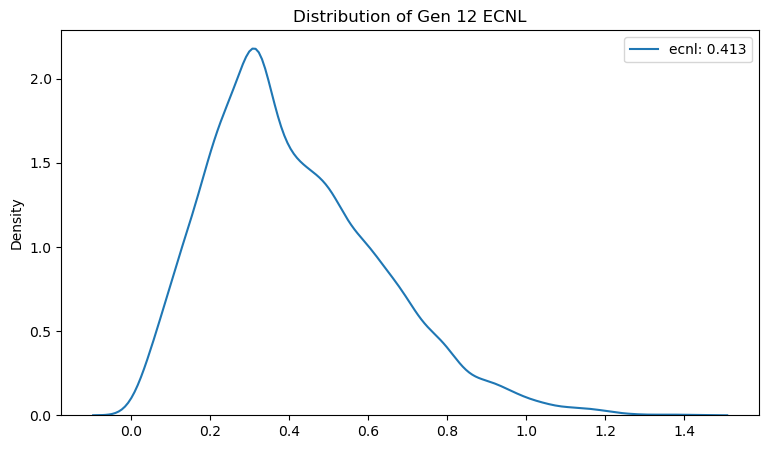

In [15]:
col = 'ecnl'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distribution of Gen 12 ECNL')
flt_mn = df_tmp[col].mean()
str_label = f'{col}: {flt_mn:0.3f}'
sns.kdeplot(list(df_tmp[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()

#### Get quantiles

In [16]:
list_cols = [
    'ecnl',
]
for col in tqdm(list_cols):
    # ml
    arr_score_quantiles = np.percentile(
        list(df_tmp[col]),
        np.linspace(0, 100, 100),
    )
    # save
    str_filename = f'arr_score_quantiles_{col}.pkl'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    pickle.dump(arr_score_quantiles, open(str_local_path, 'wb'))

100%|██████████| 1/1 [00:00<00:00, 384.59it/s]
